# Chance-constrained PULPO under uncertainty: an open example

This notebook runs PULPO's uncertainty method end to end on the bundled
`soc_demo_database`: a toy ammonia system whose hydrogen comes from steam
methane reforming (SMR) or electrolysis. It needs neither ecoinvent nor a
commercial solver: the linear programs go to HiGHS and the cone to Clarabel,
both installed with PULPO.

As of now, PULPO considers uncertainty in the biosphere flows and the
characterization factors only; technosphere exchanges are deterministic.

1. the deterministic optimum, solved in reduced space (`method='reduced'`);
2. the declared uncertainty and its closed-form moments;
3. a chance-constrained front over the reliability level $\lambda$, with an
   uncertain capacity of the electrolyzer;
4. the exact variance decomposition at a solution;
5. a screening of the parameters that declare no uncertainty;
6. an out-of-sample validation of every point, and the check that the coverage
   is exact when the impact is exactly normal;
7. the building blocks for formulations of your own.

The method is described in the documentation (*Uncertainty*). The one plot
needs `matplotlib`, which PULPO does not install; without it the plot is
skipped and everything else runs.

In [1]:
import contextlib, io
import numpy as np
import pandas as pd

from pulpo import pulpo
from pulpo.datasets.soc_demo_database import setup_soc_demo_db, METHOD_KEY
from pulpo.utils import uncertainty as unc
from pulpo.utils.utils import is_bw25

pd.set_option('display.precision', 4)
pd.set_option('display.width', 120)

quiet = io.StringIO()
with contextlib.redirect_stdout(quiet), contextlib.redirect_stderr(quiet):   # it reports every write
    setup_soc_demo_db()

## 1. The system and its deterministic optimum

One unit of ammonia is demanded. Its hydrogen comes from SMR, which emits CO₂ and
draws natural gas (with its methane leaks), or from electrolysis, which emits
nothing directly but draws much electricity. The LCIA method is GWP100 over CO₂,
CH₄ and N₂O.

In [2]:
project = 'soc_demo_project_bw25' if is_bw25() else 'soc_demo_project'
databases = ['soc_demo_background_db', 'soc_demo_foreground_db']
method = str(METHOD_KEY)

worker = pulpo.PulpoOptimizer(project, databases, {method: 1}, '')
with contextlib.redirect_stdout(io.StringIO()):
    worker.get_lci_data()
ammonia = worker.retrieve_processes(processes=['ammonia synthesis'])[0]
smr = worker.retrieve_processes(processes=['hydrogen SMR'])[0]
electrolysis = worker.retrieve_processes(processes=['hydrogen electrolysis'])[0]

choices = {'hydrogen': {smr: float('inf'), electrolysis: float('inf')}}
with contextlib.redirect_stdout(io.StringIO()):
    worker.instantiate(choices=choices, demand={ammonia: 1})

lci = worker.lci_data
process_name = lambda j: lci['process_map_metadata'][j].split(' | ')[0]
flow_name = lambda e: lci['intervention_map_metadata'][e].split(' | ')[0]
SMR, ELY = (lci['process_map'][a.key] for a in (smr, electrolysis))

With the technosphere matrix $A$ square and invertible, every scaling vector that
meets the balances is $s = s_0 + S v$ with one free variable $v_k$ per alternative.
`solve(method='reduced')` solves the LP over $v$ (here: two columns instead of six
processes) and recovers $s$ with one forward solve. The full Pyomo model gives the
same optimum.

In [3]:
with contextlib.redirect_stdout(io.StringIO()):
    worker.solve(method='reduced')
s_det = unc.current_scaling_vector(worker.instance)
reduced_impact = worker.instance.impacts[method].value

with contextlib.redirect_stdout(io.StringIO()):
    worker.solve()                                   # the full LP, HiGHS
print(f"impact, reduced: {reduced_impact:.10f}   full: {worker.instance.impacts[method].value:.10f}")
print(f"SMR {s_det[SMR]:.4f}, electrolysis {s_det[ELY]:.4f}")

impact, reduced: 1.6505600737   full: 1.6505600737
SMR 0.0000, electrolysis 0.1780


## 2. Declared uncertainty and closed-form moments

`import_declared` takes every nonzero entry of $B$ on a characterized flow and every
CF of the method, with the distribution the database declares. Parameters without
one are *undeclared*: they stay deterministic (mean = amount, variance 0) and are
listed for the screening in section 5. CO₂'s CF is exact (a normal with zero
width): CO₂ is the reference gas of GWP100.

In [4]:
data = unc.import_declared(worker)
pd.DataFrame(unc.counts(data))

,group,subgroup,status,uncertainty_type,n
0,If,soc_demo_background_db,undeclared,0,0
1,If,soc_demo_background_db,declared,2,3
2,If,soc_demo_background_db,declared,3,2
3,If,soc_demo_background_db,declared,5,1
4,If,soc_demo_foreground_db,undeclared,0,1
5,If,soc_demo_foreground_db,declared,4,1
6,Cf,"('soc demo', 'climate change')",undeclared,0,1
7,Cf,"('soc demo', 'climate change')",declared,2,1
8,Cf,"('soc demo', 'climate change')",declared,3,1


With independent inputs, $X(s)=\sum_e q_e \sum_j b_{ej} s_j$ has, for every
supported family (lognormal, normal, uniform, triangular),

$$\mathrm{E}[X] = \mu^\top s, \qquad
\mathrm{Var}\,X = \sum_j d_j s_j^2 + \sum_e w_e y_e^2,$$

with $\mu_j=\sum_e \mathrm{E}[q_e]\mathrm{E}[b_{ej}]$,
$d_j=\sum_e(\mathrm{E}[q_e]^2+\mathrm{Var}\,q_e)\mathrm{Var}\,b_{ej}$,
$w_e=\mathrm{Var}\,q_e$ and $y_e=\sum_j \mathrm{E}[b_{ej}] s_j$. The second sum is the
covariance that all processes emitting flow $e$ share through its one factor.

In [5]:
mom = unc.compute_moments(data, worker)
print(mom.summary())
print(f"at the deterministic optimum: E[X] = {mom.mean(s_det):.4f}, sigma = {mom.std(s_det):.4f}, "
      f"sigma without the shared-CF covariance = {mom.std_independent(s_det):.4f}")

{'processes': 6, 'processes_with_variance': 4, 'uncertain_cfs': 1}
at the deterministic optimum: E[X] = 1.8659, sigma = 0.8580, sigma without the shared-CF covariance = 0.8580


## 3. Chance-constrained front

The electrolyzer's capacity is uncertain: a triangular distribution between
0.005 and 0.035 with its mode at 0.03. At a joint reliability $\lambda$ the impact
target and the capacity must hold together. Boole's inequality splits the failure
budget $1-\lambda$ across the $K=2$ events, which needs no assumption on how they
depend on each other:

$$\min_s\ \mu^\top s + \kappa\,\sigma(s)\quad\text{s.t. PULPO's constraints},\quad
s_{\text{ely}} \le F_U^{-1}(\varepsilon_1),\qquad
\kappa = \Phi^{-1}(\lambda_z),\ \lambda_z = 1-\varepsilon_0 .$$

The capacity enters at its exact quantile. The impact row assumes $X$ normal
(the only normality assumption; section 6 tests it). In reduced space the
problem is a second-order cone with one column per alternative, solved by
Clarabel.

In [6]:
capacity = {'uncertainty_type': 5, 'minimum': 0.005, 'loc': 0.03, 'maximum': 0.035}
problem = unc.ChanceConstrained(worker, mom, upper_bounds={electrolysis: capacity})
front = problem.solve([0.5, 0.7, 0.9, 0.95, 0.99])

table = front.table()
table['electrolysis'] = [p.s[ELY] for p in front.values()]
table['capacity bound'] = [p.bounds[('upper', ELY)] for p in front.values()]
table

,lambda_impact,kappa,mean,sigma,adjusted,seconds,electrolysis,capacity bound
lambda,,,,,,,,
0.50,0.750,0.6745,2.1519,0.2740,2.3367,0.0096,0.0187,0.0187
0.70,0.850,1.0364,2.1574,0.2726,2.4399,0.0077,0.0156,0.0156
0.90,0.950,1.6449,2.1655,0.2720,2.6128,0.0078,0.0111,0.0111
0.95,0.975,1.9600,2.1687,0.2722,2.7023,0.0081,0.0093,0.0093
0.99,0.995,2.5758,2.1730,0.2730,2.8762,0.0063,0.0069,0.0069


Diagnostics at every point: $\sigma$ without the shared-CF covariance and the
ratio $\sigma/\sigma_{\text{indep}}$, the CFs' share of the variance.

In [7]:
unc.diagnostics(front, mom)[['sigma', 'sigma_indep', 'sigma_over_indep', 'cf_share', 'n_variables', 'n_rows']]

,sigma,sigma_indep,sigma_over_indep,cf_share,n_variables,n_rows
lambda,,,,,,
0.50,0.2740,0.2740,1.0002,0.0018,2,3
0.70,0.2726,0.2725,1.0002,0.0019,2,3
0.90,0.2720,0.2719,1.0002,0.0020,2,3
0.95,0.2722,0.2722,1.0002,0.0021,2,3
0.99,0.2730,0.2730,1.0002,0.0021,2,3


## 4. Where the variance comes from

$X$ is a sum of products of independent inputs, so its Sobol' decomposition stops
at second order and is exact:

$$S_1(b_{ej}) = \frac{\mathrm{E}[q_e]^2\,\mathrm{Var}(b_{ej})\,s_j^2}{V},\quad
S_1(q_e) = \frac{w_e y_e^2}{V},\quad
S_2(q_e,b_{ej}) = \frac{w_e\,\mathrm{Var}(b_{ej})\,s_j^2}{V},$$

and $\sum S_1+\sum S_2=1$. No sampling, no confidence intervals.

In [8]:
point = front[0.9]
dec = unc.decompose(point, mom, unc.families_by_database(worker))

def named(frame):
    label = [f"CF {flow_name(e)}" if g == 'Cf' else f"{flow_name(e)} @ {process_name(j)}"
             for g, e, j in zip(frame['group'], frame['flow'], frame['process'])]
    return frame.assign(parameter=label).set_index('parameter').drop(columns=['group', 'flow', 'process'])

print(f"sum S1 + sum S2 = {dec.parameters['S1'].sum() + dec.interactions['S2'].sum():.15f}")
named(dec.top(6))

sum S1 + sum S2 = 1.000000000000000


,family,S1,ST
parameter,,,
"Carbon dioxide, fossil @ hydrogen SMR",soc_demo_background_db,0.7908,0.7908
"Dinitrogen monoxide, fossil @ ammonia synthesis",soc_demo_foreground_db,0.1209,0.1209
"Carbon dioxide, fossil @ electricity supply",soc_demo_background_db,0.0716,0.0716
"Methane, fossil @ natural gas extraction",soc_demo_background_db,0.0144,0.0145
"CF Methane, fossil",Cf,0.0019,0.0020
"Methane, fossil @ hydrogen SMR",soc_demo_background_db,0.0001,0.0001


In [9]:
dec.families()

,S1,ST
family,,
soc_demo_background_db,0.8771,0.8772
soc_demo_foreground_db,0.1209,0.1209
Cf,0.0019,0.0020


## 5. Parameters that declare no uncertainty

Undeclared parameters are deterministic in every result above. The screening
asks what they would carry if they were uncertain: each gets the same coefficient
of variation $r$, with its mean unchanged (a lognormal, mirrored for negative
amounts), CO₂'s CF excepted. The ranking orders them by their deterministic
contribution $\mathrm{E}[q_e]\,b_{ej}\,s_j$, which fixes the order of their
total-order indices up to the CF factor and does not depend on $r$.

In [10]:
screening = unc.screen_undeclared(point, data, worker, exact_cfs=unc.co2_flows(worker), r=(0.1, 0.3))
screening.sigma

,sigma,ratio,undeclared_share
r,,,
0.1,0.2734,1.0052,0.0102
0.3,0.2844,1.0456,0.0844


In [11]:
ranking = screening.ranking.copy()
ranking.index = [f"CF {flow_name(e)}" if g == 'Cf' else f"{flow_name(e)} @ {process_name(j)}"
                 for g, e, j in zip(ranking['group'], ranking['flow'], ranking['process'])]
ranking[['amount', 'contribution', 'ST r=0.1', 'ST r=0.3']]

,amount,contribution,ST r=0.1,ST r=0.3
"CF Dinitrogen monoxide, fossil",273.00,0.2594,1.0199e-02,0.0848
"Carbon dioxide, fossil @ ammonia synthesis",0.02,0.0200,5.3523e-05,0.0004


Width sensitivity: separate widths for each database and for the CFs. At the fixed
decision the mean does not move, so the adjusted impact rises by
$\kappa\,\Delta\sigma$; re-optimizing can only do better, which makes it an upper
bound on the rise of the optimum. A re-solved point confirms it.

In [12]:
widths = [{'soc_demo_background_db': 0.3}, {'soc_demo_foreground_db': 0.3}, {'Cf': 0.3}, 0.3]
sensitivity = unc.width_sensitivity(point, data, worker, widths, exact_cfs=unc.co2_flows(worker))

wide = unc.compute_moments(unc.widen(data, 0.3, unc.co2_flows(worker)), worker)
resolved = unc.ChanceConstrained(worker, wide, upper_bounds={electrolysis: capacity}).solve_point(0.9)
print(f"re-solved at r = 0.3: the optimum rises by {resolved.adjusted - point.adjusted:.5f} "
      f"(bound {sensitivity['bound'].iloc[-1]:.5f})")
sensitivity

re-solved at r = 0.3: the optimum rises by 0.02039 (bound 0.02039)


,r[soc_demo_background_db],r[soc_demo_foreground_db],r[Cf],sigma,ratio,delta_sigma,bound
0,0.3,0.0,0.0,0.2720,1.0000,0.0000e+00,0.0000
1,0.0,0.3,0.0,0.2720,1.0002,6.6176e-05,0.0001
2,0.0,0.0,0.3,0.2843,1.0453,1.2331e-02,0.0203
3,0.3,0.3,0.3,0.2844,1.0456,1.2395e-02,0.0204


## 6. Out-of-sample validation

Each solution is held fixed and every declared input is drawn from its own family
(not a fitted normal), together with the capacity: $N = 200{,}000$ draws, each
parameter from its own stream keyed by one recorded seed, the same draws for
every decision. Per point: the coverage of the
impact row against $\lambda_z$, of the capacity against $1-\varepsilon_1$, and of both
together against $\lambda$, with Wilson intervals; the normal-approximation error
of the $\lambda_z$ quantile; skewness; the empirical and the Gaussian CVaR; and the
regret against the lowest level and against the best point of the front in each
draw. The deterministic optimum is priced on the same draws.

In [13]:
validation = unc.validate(front, problem, data, n=200_000, seed=2026, designs={'deterministic': s_det})
columns = ['lambda_impact', 'coverage', 'coverage_low', 'coverage_high', f'nominal upper:{ELY}',
           f'coverage upper:{ELY}', 'joint_coverage', 'quantile_error', 'skew']
validation.table[columns]

lambda_impact  coverage  coverage_low  coverage_high  nominal upper:4  coverage upper:4  \
design        lambda                                                                                            
front         0.50            0.750    0.7618        0.7599         0.7636            0.750            0.7507   
              0.70            0.850    0.8513        0.8498         0.8529            0.850            0.8495   
              0.90            0.950    0.9416        0.9405         0.9426            0.950            0.9499   
              0.95            0.975    0.9660        0.9652         0.9668            0.975            0.9753   
              0.99            0.995    0.9897        0.9893         0.9902            0.995            0.9948   
deterministic 0.50            0.750    0.7755        0.7736         0.7773            0.750            0.0000   
              0.70            0.850    0.8036        0.8018         0.8053            0.850            0.0000   
              0.90            0.950    0.8425        0.8409         0.8441            0.950            0.0000   
              0.95            0.975    0.8602        0.8587         0.8618            0.975            0.0000   
              0.99            0.995    0.8887        0.8873         0.8901            0.995            0.0000   

                      joint_coverage  quantile_error    skew  
design        lambda                                          
front         0.50            0.5705         -0.0111  0.3829  
              0.70            0.7229         -0.0018  0.3661  
              0.90            0.8944          0.0255  0.3542  
              0.95            0.9422          0.0449  0.3529  
              0.99            0.9846          0.0946  0.3535  
deterministic 0.50            0.0000         -0.0842  1.7324  
              0.70            0.0000          0.2100  1.7324  
              0.90            0.0000          0.8849  1.7324  
              0.95            0.0000          1.3520  1.7324  
              0.99            0.0000          2.5319  1.7324

In [14]:
validation.table[['threshold', 'cvar_gaussian', 'cvar_empirical', 'regret_vs_lowest_lambda_mean',
                  'regret_vs_front_best_mean']].loc['front']

,threshold,cvar_gaussian,cvar_empirical,regret_vs_lowest_lambda_mean,regret_vs_front_best_mean
lambda,,,,,
0.50,2.3367,2.5002,2.5133,0.0000,0.0143
0.70,2.4399,2.5811,2.6065,0.0055,0.0198
0.90,2.6128,2.7265,2.7817,0.0135,0.0278
0.95,2.7023,2.8051,2.8806,0.0167,0.0310
0.99,2.8762,2.9626,3.0904,0.0210,0.0352


The impact is right-skewed here (the lognormal CO₂ emission of SMR dominates its
variance), so the Gaussian quantile sits below the empirical one at high
reliability: the impact row holds slightly less often than it claims, the joint
event falls short of $\lambda$ by a similar margin, and the empirical CVaR exceeds
the Gaussian one. The capacity holds at its nominal level, since it enters at its
exact quantile. The deterministic optimum was solved without the capacity and
runs the electrolyzer at 0.178, above the capacity's maximum, so the bound never
holds.

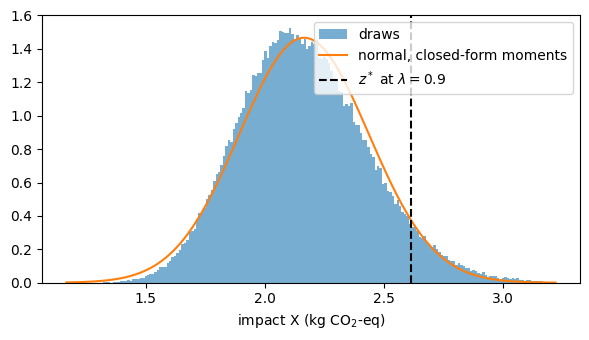

In [15]:
import scipy.stats
try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None
    print('matplotlib is not installed: the plot is skipped.')

if plt is not None:
    k = validation.decisions.index('lambda=0.9')
    x = validation.impacts[k]
    grid = np.linspace(x.min(), np.quantile(x, 0.9995), 400)
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.hist(x, bins=200, range=(grid[0], grid[-1]), density=True, alpha=0.6, label='draws')
    ax.plot(grid, scipy.stats.norm.pdf(grid, point.mean, point.sigma), label='normal, closed-form moments')
    ax.axvline(point.adjusted, color='k', ls='--', label=r'$z^*$ at $\lambda = 0.9$')
    ax.set_xlabel('impact X (kg CO$_2$-eq)'); ax.legend(); fig.tight_layout()

**When $X$ is exactly normal, the coverage is exact.** Replace every declared $B$
entry by a normal with the same mean and variance and make the CFs exact: then $X$
is normal, and the empirical coverage of the impact row must equal $\lambda_z$ up to
Monte Carlo error. This is the check that separates the method from its one
approximation.

In [16]:
import copy
normal = copy.deepcopy(data)
for db, block in normal['If'].items():
    specs = {}
    for index, spec in block['defined'].items():
        mean, var = unc.spec_moments(spec)
        specs[index] = {'uncertainty_type': 3, 'loc': mean, 'scale': var ** 0.5}
    unc.override(normal, 'If', db, specs)
unc.override(normal, 'Cf', method, {e: {'uncertainty_type': 1} for e in normal['Cf'][method]['defined']})

normal_problem = unc.ChanceConstrained(worker, unc.compute_moments(normal, worker),
                                       upper_bounds={electrolysis: capacity})
normal_front = normal_problem.solve([0.5, 0.9, 0.99])
check = unc.validate(normal_front, normal_problem, normal, n=200_000, seed=7).table.loc['front']
check.assign(se=np.sqrt(check['lambda_impact'] * (1 - check['lambda_impact']) / 200_000))[
    ['lambda_impact', 'coverage', 'se', 'coverage_low', 'coverage_high', 'skew']]

,lambda_impact,coverage,se,coverage_low,coverage_high,skew
lambda,,,,,,
0.50,0.750,0.7511,0.0010,0.7492,0.7530,-0.0030
0.90,0.950,0.9506,0.0005,0.9496,0.9515,-0.0032
0.99,0.995,0.9949,0.0002,0.9946,0.9952,-0.0034


## 7. Building blocks

The reduced system and the sampler are public, so a study can formulate its own
problem on top of them, e.g. a scenario-based CVaR front. `problem.projections()`
returns $s_0$, $\mathrm{E}[X]=m_0+m^\top v$, the rows of $S$ on the processes that
carry variance and $\mathrm{E}[B_u]S$; `draw_parameters` returns draws of the declared
parameters as arrays. Together they give the sampled impact of the base and of
one unit of each alternative without further solves.

In [17]:
p = problem.projections()
draws = unc.draw_parameters(data, 1000, rng=1, processes=p.J)
print(f"m0 = {p.m0:.4f}, m = {np.round(p.m, 4)}, S_J {p.S_J.shape}, B_u S {p.B_unc_S.shape}, "
      f"draws: B {draws.B.shape}, CFs {draws.Q.shape}")

m0 = 1.8659, m = [10.634   8.8386], S_J (4, 2), B_u S (1, 2), draws: B (7, 1000), CFs (2, 1000)
